##                                     Интернет-магазине «Стримчик»
   Я работаю в интернет-магазине «Стримчик», который продаёт по всему миру компьютерные игры. Из открытых источников доступны исторические данные о продажах игр, оценки пользователей и экспертов, жанры и платформы (например, Xbox или PlayStation). Мне нужно выявить определяющие успешность игры закономерности. Это позволит сделать ставку на потенциально популярный продукт и спланировать рекламные кампании.
Передо мной данные до 2016 года. Представим, что сейчас декабрь 2016 г., и я планирую кампанию на 2017-й. Нужно отработать принцип работы с данными. Неважно, прогнозирую ли я продажи на 2017 год по данным 2016-го или же 2027-й — по данным 2026 года.
В наборе данных попадается аббревиатура ESRB (Entertainment Software Rating Board) — это ассоциация, определяющая возрастной рейтинг компьютерных игр. ESRB оценивает игровой контент и присваивает ему подходящую возрастную категорию, например, «Для взрослых», «Для детей младшего возраста» или «Для подростков».

###    Цель проекта
 Выявить определяющие успешность закономерности для игр для планирования рекламных акций на следующий год.

######         **План Проекта:**

1. Шаг 1. Откроем файл с данными и изучите общую информацию
1.1. Путь к файлу: /datasets/games.csv. Скачать датасет
2. Шаг 2. Подготовим данные
2.1 Заменим названия столбцов (приведем к нижнему регистру);
2.2 Преобразуем данные в нужные типы. Опишем, в каких столбцах заменили тип данных и почему;
2.3 Обработаем пропуски при необходимости:
    Объясним, почему заполнили пропуски определённым образом или почему не станем это делать;
    Опишем причины, которые могли привести к пропускам;
2.4 Обратим внимание на аббревиатуру 'tbd' в столбце с оценкой пользователей. Отдельно разберем это значение и опишем, как его обработать;
2.5. Посчитаем суммарные продажи во всех регионах и запишите их в отдельный столбец.
3. Шаг 3. Проведем исследовательский анализ данных
3.1 Посмотрим, сколько игр выпускалось в разные годы. Важны ли данные за все периоды?
3.2 Посмотрим, как менялись продажи по платформам. 
    Выберем платформы с наибольшими суммарными продажами и построем распределение по годам. 
3.2.1 За какой характерный срок появляются новые и исчезают старые платформы?
    Возьмем данные за соответствующий актуальный период. Актуальный период определим самостоятельно в результате исследования предыдущих вопросов. Основной фактор — эти данные помогут построить прогноз на 2017 год.
Не учитываем в работе данные за предыдущие годы.
3.2.2 Какие платформы лидируют по продажам, растут или падают? Выберем несколько потенциально прибыльных платформ.
3.2.3 Построем график «ящик с усами» по глобальным продажам игр в разбивке по платформам. Опишем результат.
3.2.4 Посмотрим, как влияют на продажи внутри одной популярной платформы отзывы пользователей и критиков. Построем диаграмму рассеяния и посчитаем корреляцию между отзывами и продажами. Сформулируем выводы.
3.2.5 Соотнесем выводы с продажами игр на других платформах.
Посмотрим на общее распределение игр по жанрам. Что можно сказать о самых прибыльных жанрах? Выделяются ли жанры с высокими и низкими продажами?
4. Шаг 4. Составим портрет пользователя каждого региона
   Определим для пользователя каждого региона (NA, EU, JP):
4.1 Самые популярные платформы (топ-5). Опишем различия в долях продаж.
4.2 Самые популярные жанры (топ-5). Поясним разницу.
4.3 Влияет ли рейтинг ESRB на продажи в отдельном регионе?
5. Шаг 5. Проверим гипотезы
5.1 Средние пользовательские рейтинги платформ Xbox One и PC одинаковые;
5.2 Средние пользовательские рейтинги жанров Action (англ. «действие», экшен-игры) и Sports (англ. «спортивные соревнования») разные.
Зададим самостоятельно пороговое значение alpha.
Поясним:
5.3 Как я сформулировала нулевую и альтернативную гипотезы;
5.4 Какой критерий применила для проверки гипотез и почему.
6. Шаг 6. Напишем общий вывод

## 1. Откроем файл с данными и изучии общую информацию

In [1]:
import pandas as pd# импортируйте библиотеки
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', 50) 
import math 
import scipy.stats as st
from scipy.stats import binom
import numpy as np
from scipy.stats import f_oneway
import seaborn as sns

In [2]:
data = pd.read_csv('/datasets/games.csv', sep=',') # откроем наш файл

In [3]:
display(data.head(20)) # посмотрим информацию по данным
display(data.info())
display(data.shape)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


None

(16715, 11)

Исходя из данных, которые мы видим мне потребуется некоторые столбцы привести к типу даты pandas, проверить наличие пропущенных значений и дубликатов в датафреймах, обработать их, если такие значения присутствуют. Сделаем это в следующем шаге.

## 2. Подготовим данные

In [4]:
# Заменим названия столбцов
data['Name'] = data['Name'].str.lower() # Приводим все значения к нижнему регистру
data['Name'] = data['Name'].str.strip() # Удаляем лишние пробелы в начале и конце строки

data['Platform'] = data['Platform'].str.lower() # Приводим все значения к нижнему регистру
data['Platform'] = data['Platform'].str.strip() # Удаляем лишние пробелы в начале и конце строки

data['Genre'] = data['Genre'].str.lower() # Приводим все значения к нижнему регистру
data['Genre'] = data['Genre'].str.strip() # Удаляем лишние пробелы в начале и конце строки

In [5]:
# Проверим на дубликаты
duplicates = data.duplicated()
# Удалим на дубликаты
data = data.drop_duplicates()

Преобразуем данные в нужные типы. 
Опишем, в каких столбцах заменили тип данных и почему:
  Преобразуем столбец "Year_of_Release" из типа float в тип дата: Поскольку год выпуска является тип данных даты.
Преобразуем столбец "Critic_Score" из типа float в тип integer: Оценки критиков обычно являются целыми числами, поэтому логично представить их в виде целых чисел.
  Преобразуем столбец "User_Score" из типа object в тип float: Рейтинг пользователей является числовым значением, поэтому логично представить его в виде числа с плавающей запятой, а не в виде объекта. 
Оставим остальные столбцы без изменений, поскольку их текущие типы данных соответствуют их значениям.

In [6]:
# Преобразуем столбец "Year_of_Release" из типа float в тип дата
data['Year_of_Release'] = pd.to_datetime(data['Year_of_Release'], format='%Y').dt.year


In [7]:
# Преобразуем столбец "Critic_Score" из типа float в тип integer
data['Critic_Score'] = data['Critic_Score'].apply(lambda item: item if np.isnan(item) else int (item))

In [8]:
# Преобразуем столбец "User_Score" из типа object в тип float
# Заменить "tbd" на пропущенные значения (NaN)
data['User_Score'] = data['User_Score'].replace('tbd', np.nan)

# Преобразовать столбец в тип float
data['User_Score'] = data['User_Score'].astype(float)

In [9]:
missing_values = data.isnull().sum()# считаем количество пропусков по каждому столбцу
missing_percentage = (missing_values / len(data)) * 100
missing_data = pd.concat([missing_values, missing_percentage], axis=1, keys=['Количество', 'Процент'])
print(missing_data)

                 Количество    Процент
Name                      2   0.011965
Platform                  0   0.000000
Year_of_Release         269   1.609333
Genre                     2   0.011965
NA_sales                  0   0.000000
EU_sales                  0   0.000000
JP_sales                  0   0.000000
Other_sales               0   0.000000
Critic_Score           8578  51.319174
User_Score             9125  54.591684
Rating                 6766  40.478612


В шести солбцах у нас пропуски. Заполним их.

In [10]:
# Обработаем пропуски по столбцу Name, заменила на unknown, так как значение не критично
data['Name'].fillna('unknown', inplace=True)

In [11]:
# Обработаем пропуски по столбцу Year_of_Release
data['Year_of_Release'].fillna('unknown', inplace=True)

In [12]:
# Обработаем пропуски по столбцу Genre
data.dropna(subset=['Genre'], inplace=True)

In [13]:
data['Critic_Score'].fillna('unknown', inplace=True)

In [14]:
# Обработаем пропуски по столбцу User_Score
data['User_Score'] = data['User_Score'].replace('unknown', np.nan)

In [15]:
# Обработаем пропуски по столбцу Rating, заменила на unknown, так как не во всех странах присвается одинаковый рейтинг по одним и тем же играм, и есть где вообще нет рейтинга.
data['Rating'].fillna('unknown', inplace=True)

  Объясните, почему заполнили пропуски определённым образом или почему не стали это делать:
1. Пропуски по столбцу Critic_Score и User_Score, Rating не заполняла, а заменила на unknown так как процент пропусков очень большой и заполнение может повлиять на анализ.
2. Пропуски в столбце Name заменила на unknown, так как само имя нам не важно. Оно не несет нужной для анилиза информаци и меньше 5 процентов.
3. Пропуски в столбце Year_of_Release заменила на unknown, так как данная информация может отличаться от платформы к платформе по одной и той же игре.
4. Пропуски в столбце Genre заменила на удалила, так как их меньше 5 процентов и на анализ они не повлияют

Опишите причины, которые могли привести к пропускам;

Пропуски по столбцам Critic_Score и User_Score, Rating и Year_of_Release могли образоваться так как не во всех странах эти данные присваиваются.
Пропуски в столбце Name могли образоваться в следствии человеческого фактора (не все люди заполняют данное поле).
Пропуски в столбце Genre могли образовать из за не верного переноса данных либо утери данных в процеесе работы и создания файла.

   Обратим внимание на аббревиатуру 'tbd' в столбце с оценкой пользователей. Отдельно разберем это значение и опишем, как его обработать:
  Аббревиатура "tbd" в контексте столбца оценки пользователей обычно означает "to be determined" или "будет определено". "tbd" обычно используется для обозначения того, что оценка еще не была присвоена или ее еще нет в настоящее время.
  При обработке столбца с оценкой пользователей, значение "tbd" может считаться недействительным значением (так как оно не может быть числовым). Для обработки значения "tbd", я преобразовала его в пропущенное значение (NaN), чтобы отразить неопределенность.

In [16]:
# Посчитайте суммарные продажи во всех регионах и запишите их в отдельный столбец.
data['Total_Sales'] = data['NA_sales'] + data['EU_sales'] + data['JP_sales'] + data['Other_sales']
display(data.head(20))

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating,Total_Sales
0,wii sports,wii,2006.0,sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,super mario bros.,nes,1985.0,platform,29.08,3.58,6.81,0.77,unknown,NaN,unknown,40.24
2,mario kart wii,wii,2008.0,racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,wii sports resort,wii,2009.0,sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,pokemon red/pokemon blue,gb,1996.0,role-playing,11.27,8.89,10.22,1.00,unknown,NaN,unknown,31.38
5,tetris,gb,1989.0,puzzle,23.20,2.26,4.22,0.58,unknown,NaN,unknown,30.26
6,new super mario bros.,ds,2006.0,platform,11.28,9.14,6.50,2.88,89.0,8.5,E,29.80
7,wii play,wii,2006.0,misc,13.96,9.18,2.93,2.84,58.0,6.6,E,28.91
8,new super mario bros. wii,wii,2009.0,platform,14.44,6.94,4.70,2.24,87.0,8.4,E,28.32
9,duck hunt,nes,1984.0,shooter,26.93,0.63,0.28,0.47,unknown,NaN,unknown,28.31


In [17]:
# Проверка на не явные дубликаты
duplicates = data.duplicated().any()
print(duplicates)

False


In [18]:
# Проверка наличия дубликатов, учитывая столбцы 'Name', 'Platform', 'Year_of_Release'
duplicates = data.duplicated(subset=['Name', 'Platform', 'Year_of_Release'], keep=False)

# Подсчет количества дубликатов
num_duplicates = duplicates.sum()

# Определение процента дубликатов
duplicate_percentage = (num_duplicates / len(data)) * 100

# Вывод процента дубликатов
print(f"Процент дубликатов: {duplicate_percentage}%")

# Удаление дубликатов, учитывая только столбцы 'Name', 'Platform', 'Year_of_Release'
data = data.drop_duplicates(subset=['Name', 'Platform', 'Year_of_Release'])

# Вывод обновленного датафрейма
print(data)

Процент дубликатов: 0.011966732483695326%
                                Name Platform Year_of_Release         Genre  \
0                         wii sports      wii          2006.0        sports   
1                  super mario bros.      nes          1985.0      platform   
2                     mario kart wii      wii          2008.0        racing   
3                  wii sports resort      wii          2009.0        sports   
4           pokemon red/pokemon blue       gb          1996.0  role-playing   
...                              ...      ...             ...           ...   
16710  samurai warriors: sanada maru      ps3          2016.0        action   
16711               lma manager 2007     x360          2006.0        sports   
16712        haitaka no psychedelica      psv          2016.0     adventure   
16713               spirits & spells      gba          2003.0      platform   
16714            winning post 8 2016      psv          2016.0    simulation   

       NA

####### Вывод: 
 Все значения мы привели к нижнему регистру.
 Преобразовали столбец "Year_of_Release" из типа float в тип дата: Поскольку год выпуска является тип данных даты.
 Преобразовали столбец "Critic_Score" из типа float в тип integer: Оценки критиков обычно являются целыми числами, поэтому логично представить их в виде целых чисел. 
 Преобразовали столбец "User_Score" из типа object в тип float: Рейтинг пользователей является числовым значением, поэтому логично представить его в виде числа с плавающей запятой, а не в виде объекта. 
 Оставили остальные столбцы без изменений, поскольку их текущие типы данных соответствуют их значениям.
 Нашли и заполнили пропуски:
1. Пропуски по столбцу Critic_Score и User_Score, Rating не заполняла, а заменила на unknown так как процент пропусков очень большой и заполнение может повлиять на анализ.
2. Пропуски в столбце Name заменила на unknown, так как само имя нам не важно. Оно не несет нужной для анилиза информаци и меньше 5 процентов.
3. Пропуски в столбце Year_of_Release заменила на unknown, так как данная информация может отличаться от платформы к платформе по одной и той же игре.
4. Пропуски в столбце Genre удалила, так как их меньше 5 процентов и на анализ они не повлияют
 Пропуски по столбцам Critic_Score и User_Score, Rating и Year_of_Release могли образоваться так как не во всех странах эти данные присваиваются.
 Пропуски в столбце Name могли образоваться в следствии человеческого фактора (не все люди заполняют данное поле).
 Пропуски в столбце Genre могли образовать из за не верного переноса данных либо утери данных в процеесе работы и создания файла.
 
 Проверила и удалила не явные дубликаты

## 3. Проведем исследовательский анализ данных:

In [19]:
# Посмотрим, сколько игр выпускалось в разные годы. Важны ли данные за все периоды?
data['Year_of_Release'] = data['Year_of_Release'].replace('unknown', np.nan)
game_counts_by_year = data['Year_of_Release'].value_counts().sort_index()
data['game_counts_by_year'] = game_counts_by_year
display(game_counts_by_year)

1980.0       9
1981.0      46
1982.0      36
1983.0      17
1984.0      14
1985.0      14
1986.0      21
1987.0      16
1988.0      15
1989.0      17
1990.0      16
1991.0      41
1992.0      43
1993.0      60
1994.0     121
1995.0     219
1996.0     263
1997.0     289
1998.0     379
1999.0     338
2000.0     350
2001.0     482
2002.0     829
2003.0     775
2004.0     762
2005.0     939
2006.0    1006
2007.0    1197
2008.0    1427
2009.0    1426
2010.0    1255
2011.0    1136
2012.0     652
2013.0     544
2014.0     581
2015.0     606
2016.0     502
Name: Year_of_Release, dtype: int64

Посмотрите, сколько игр выпускалось в разные годы. Важны ли данные за все периоды?
С моей точки, зрения все периоды не важны.

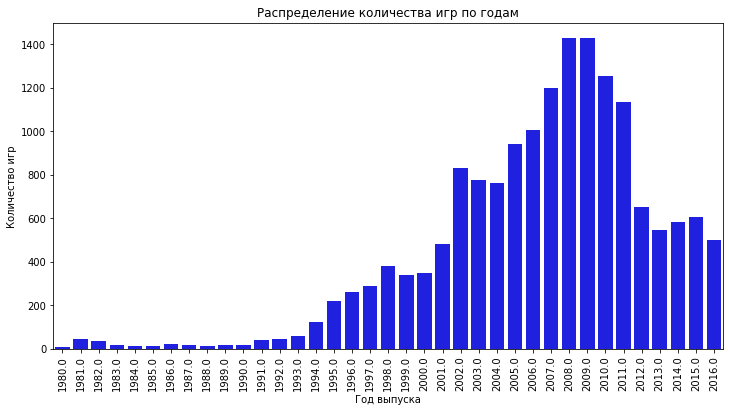

In [20]:
# Визуализация распределения количества игр по годам
plt.figure(figsize=(12, 6))
sns.barplot(x=game_counts_by_year.index, y=game_counts_by_year.values, color='blue')
plt.xticks(rotation=90)
plt.xlabel('Год выпуска')
plt.ylabel('Количество игр')
plt.title('Распределение количества игр по годам')
plt.show()

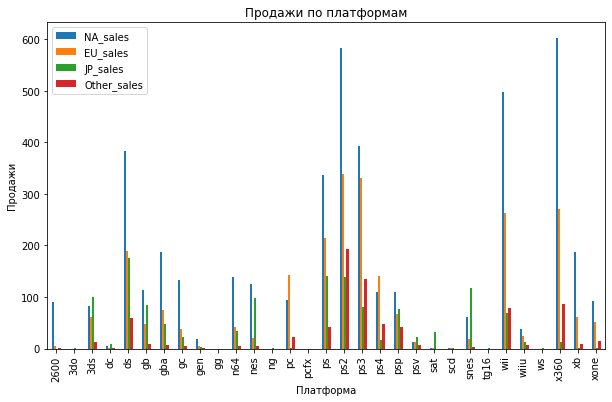

In [21]:
# Исследуем, как менялись продажи по платформам
data = data[data['Year_of_Release'] != '1980']  # Удаление данных для 1985 года
sales_by_platform = data.groupby('Platform')[['NA_sales', 'EU_sales', 'JP_sales', 'Other_sales']].sum()
# Визуализация
sales_by_platform.plot(kind='bar', figsize=(10, 6))
plt.title('Продажи по платформам')
plt.xlabel('Платформа')
plt.ylabel('Продажи')
plt.show()

In [22]:
# Выберем платформы с наибольшими суммарными продажами
top_platforms = sales_by_platform.sum(axis=1).nlargest(5).index
display(top_platforms)

Index(['ps2', 'x360', 'ps3', 'wii', 'ds'], dtype='object', name='Platform')

                       Name Platform  Year_of_Release         Genre  NA_sales  \
0                wii sports      wii           2006.0        sports     41.36   
1         super mario bros.      nes           1985.0      platform     29.08   
2            mario kart wii      wii           2008.0        racing     15.68   
3         wii sports resort      wii           2009.0        sports     15.61   
4  pokemon red/pokemon blue       gb           1996.0  role-playing     11.27   

   EU_sales  JP_sales  Other_sales Critic_Score  User_Score   Rating  \
0     28.96      3.77         8.45         76.0         8.0        E   
1      3.58      6.81         0.77      unknown         NaN  unknown   
2     12.76      3.79         3.29         82.0         8.3        E   
3     10.93      3.28         2.95         80.0         8.0        E   
4      8.89     10.22         1.00      unknown         NaN  unknown   

   Total_Sales  game_counts_by_year  
0        82.54                  NaN  
1   

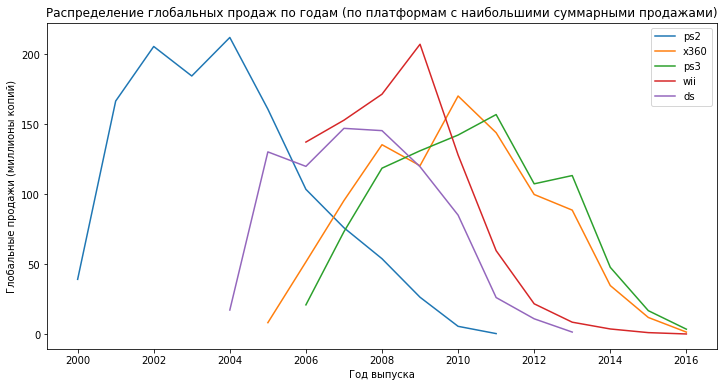

In [23]:
# Построем распределение продаж по годам для выбранных платформ
display(data.head())

data = data[data['Year_of_Release'] != 1985]
plt.figure(figsize=(12, 6))
for platform in top_platforms:
    sales_by_year = data[data['Platform'] == platform].groupby('Year_of_Release')[['Total_Sales']].sum()
    plt.plot(sales_by_year.index, sales_by_year['Total_Sales'], label=platform)
plt.xlabel('Год выпуска')
plt.ylabel('Глобальные продажи (миллионы копий)')
plt.title('Распределение глобальных продаж по годам (по платформам с наибольшими суммарными продажами)')
plt.legend()

#data = data[data['Year_of_Release'] != 1985] Удаление данных для года 1985 и проверка отсутствия 1985

print(data.head())

plt.show()

In [24]:
 # Создаем срез данных по актуальному периоду
filtered_data = data.query('Year_of_Release > 2013')

In [25]:
filtered_data

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating,Total_Sales,game_counts_by_year
31,call of duty: black ops 3,ps4,2015.0,shooter,6.03,5.86,0.36,2.38,unknown,NaN,unknown,14.63,NaN
42,grand theft auto v,ps4,2014.0,action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62,NaN
47,pokemon omega ruby/pokemon alpha sapphire,3ds,2014.0,role-playing,4.35,3.49,3.10,0.74,unknown,NaN,unknown,11.68,NaN
77,fifa 16,ps4,2015.0,sports,1.12,6.12,0.06,1.28,82.0,4.3,E,8.58,NaN
87,star wars battlefront (2015),ps4,2015.0,shooter,2.99,3.49,0.22,1.28,unknown,NaN,unknown,7.98,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16703,strawberry nauts,psv,2016.0,adventure,0.00,0.00,0.01,0.00,unknown,NaN,unknown,0.01,NaN
16707,aiyoku no eustia,psv,2014.0,misc,0.00,0.00,0.01,0.00,unknown,NaN,unknown,0.01,NaN
16710,samurai warriors: sanada maru,ps3,2016.0,action,0.00,0.00,0.01,0.00,unknown,NaN,unknown,0.01,NaN
16712,haitaka no psychedelica,psv,2016.0,adventure,0.00,0.00,0.01,0.00,unknown,NaN,unknown,0.01,NaN


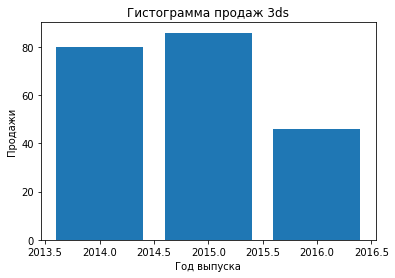

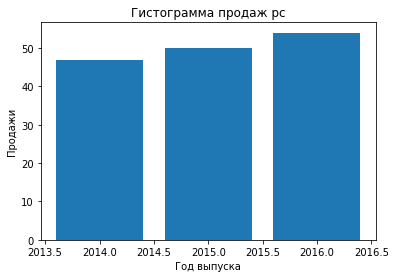

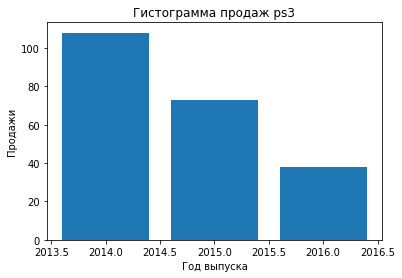

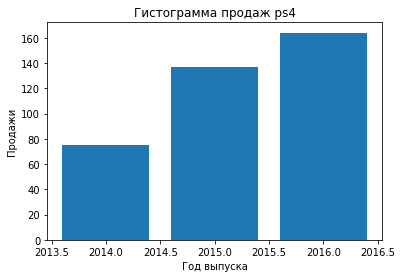

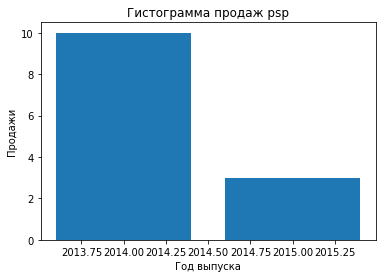

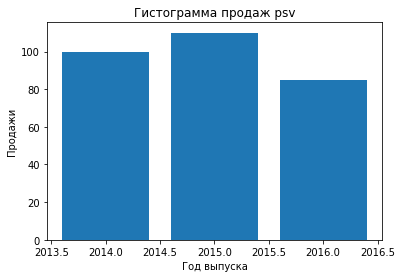

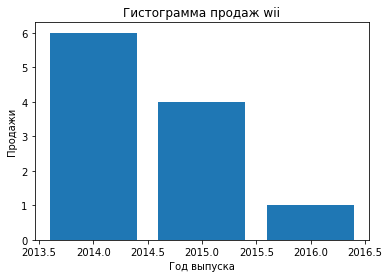

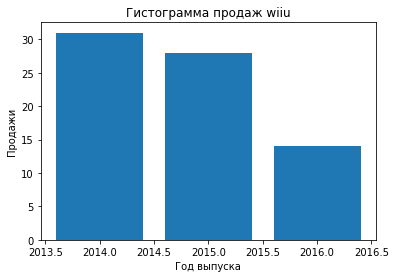

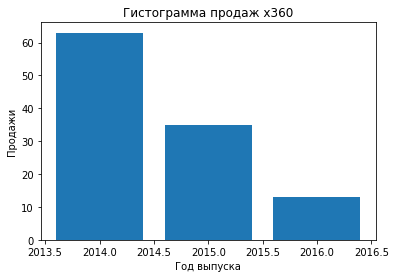

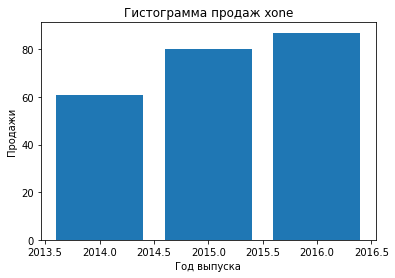

In [26]:
# Группировка данных по платформам и годам выпуска
platform_year_counts = filtered_data.groupby(["Platform", "Year_of_Release"]).size().reset_index(name='Count')

# Получение уникальных платформ и годов выпуска
platforms = platform_year_counts["Platform"].unique()
years = platform_year_counts["Year_of_Release"].unique()

# Построение гистограмм для каждой платформы
for platform in platforms:
    platform_data = platform_year_counts[platform_year_counts["Platform"] == platform]
    
    plt.figure()
    plt.bar(platform_data["Year_of_Release"], platform_data["Count"])
    plt.xlabel("Год выпуска")
    plt.ylabel("Продажи")
    plt.title(f"Гистограмма продаж {platform}")
    plt.show()


Platform
3ds      86.68
pc       27.05
ps3      68.18
ps4     288.15
psp       0.36
psv      22.40
wii       5.07
wiiu     42.98
x360     48.22
xone    140.36
Name: Total_Sales, dtype: float64


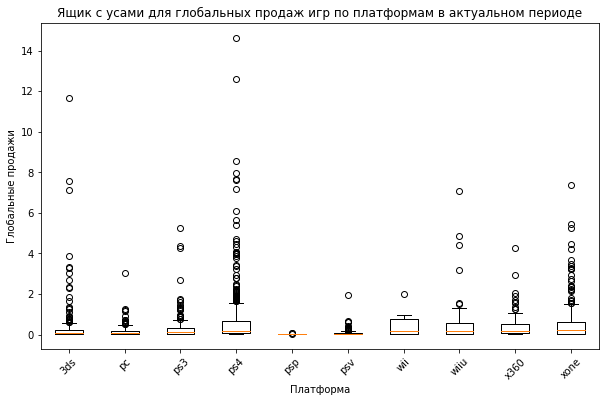

In [27]:
# Группировка данных по платформам и глобальным продажам
platform_sales = filtered_data.groupby('Platform')['Total_Sales'].sum()
print(platform_sales)

# Построение графика "ящик с усами"
plt.figure(figsize=(10, 6))
data_for_boxplot = []

for platform in platform_sales.index:
    data_for_boxplot.append(filtered_data.loc[filtered_data['Platform'] == platform, 'Total_Sales'].values)

plt.boxplot(data_for_boxplot)
plt.xticks(range(1, len(platform_sales) + 1), platform_sales.index, rotation=45)
plt.xlabel('Платформа')
plt.ylabel('Глобальные продажи')
plt.title('Ящик с усами для глобальных продаж игр по платформам в актуальном периоде')

plt.show()

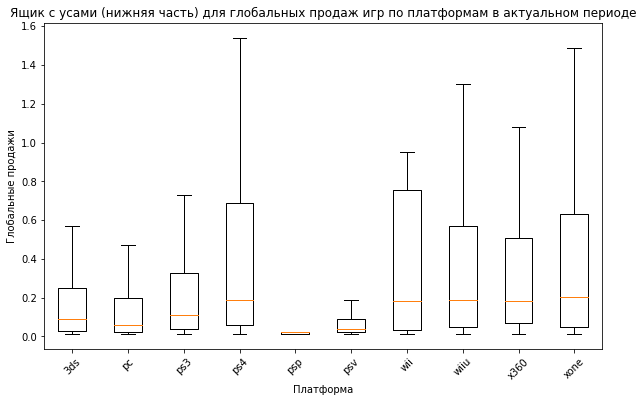

In [28]:
# Построение дополнительного графика только с нижней частью boxplot-ов
plt.figure(figsize=(10, 6))
plt.boxplot(data_for_boxplot, showfliers=False)
plt.xticks(range(1, len(platform_sales) + 1), platform_sales.index, rotation=45)
plt.xlabel('Платформа')
plt.ylabel('Глобальные продажи')
plt.title('Ящик с усами (нижняя часть) для глобальных продаж игр по платформам в актуальном периоде')

plt.show()

#####  Интрепретируем данные по каждой из платформ:
3ds медиана между ближе к 0.1, верхний квартиль чуть превышает отметку 0.2, нижний- ближе к 0. Межквартильный размах доходит до значений 0.6, что указывает на  выбросы, то есть значения, которые существенно отличаются от остальных значений набора данных. Такие значения могут быть потенциально необычными или ошибочными.
pc медиана между ближе к 0.1, верхний квартиль доходит до отметки 0.2, нижний- ближе к 0. Межквартильный размах доходит до значений 0.5.
ps3 медиана между ближе к 0.1, верхний квартиль доходит до отметки 0.3, нижний- ближе к 0. Межквартильный размах доходит до значений 0.7.
ps4 медиана между ближе к 0.2, верхний квартиль доходит до отметки 0.7, нижний- ближе к 0. Межквартильный размах доходит до значений 1.7.
Платформу psp интрептировать не будем, так как ее перестали поддерживать и игры на нее не выпускают.
psv медиана между ближе к 0, верхний квартиль доходит до отметки 0.1, нижний- ближе к 0. Межквартильный размах доходит до значений 0.2.
wii медиана между ближе к 0.2, верхний квартиль доходит до отметки 0.7, нижний- ближе к 0. Межквартильный размах доходит до значений 1.0.
wiiu медиана между ближе к 0.2, верхний квартиль доходит до отметки 0.6, нижний- ближе к 0,1. Межквартильный размах доходит до значений 1.4.
x360 медиана между ближе к 0.2, верхний квартиль доходит до отметки 0.5, нижний- ближе к 0,1. Межквартильный размах доходит до значений 1.1.
xone медиана между превышает 0.2, верхний квартиль доходит до отметки 0.6, нижний- ближе к 0,1. Межквартильный размах доходит до значений 1.5.

Вывод: платформы, которые умирают:psv и psp. Как не грустно, но платформа pc скорее всего тоже скоро умрет.
Самый большой квартильный размах у wii и ps4, далее xone и wiiu.

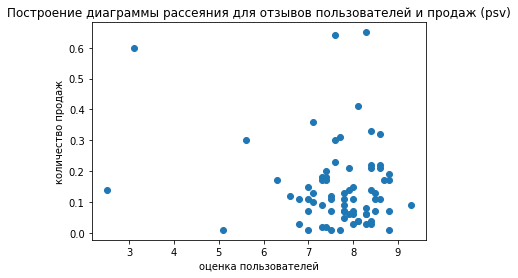

In [29]:
# Внутри одной платформы (например, psv)

# Создание подмножества данных для платформы xone
psv_data = filtered_data[filtered_data['Platform'] == 'psv']

# Удаление строки со значениями NaN в столбцах 'User_Score' и 'Critic_Score'
psv_data.dropna(subset=['User_Score', 'Critic_Score'], inplace=True)

# Построение диаграммы рассеяния для отзывов пользователей и продаж
plt.scatter(psv_data['User_Score'], psv_data['Total_Sales'])
plt.xlabel('оценка пользователей')
plt.ylabel('количество продаж')
plt.title('Построение диаграммы рассеяния для отзывов пользователей и продаж (psv)')
plt.show()

In [30]:
# Вычисление коэффициента корреляции между отзывами пользователей и продажами
correlation = psv_data['User_Score'].corr(psv_data['Total_Sales'])
print('Корреляция между отзывами пользователей и продажами:', correlation)

Корреляция между отзывами пользователей и продажами: -0.16845504978064446


In [31]:
# Приведение столбца Total_Sales и Critic_Score к типу float 
filtered_data['Critic_Score'] = filtered_data['Critic_Score'].replace('unknown', np.nan)
filtered_data['Total_Sales'] = filtered_data['Total_Sales'].replace('unknown', np.nan)

filtered_data['Critic_Score'] = filtered_data['Critic_Score'].astype(float)
filtered_data['Total_Sales'] = filtered_data['Total_Sales'].astype(float)

# Вычисление коэффициента корреляции между оценкой критиков и продажами
correlation = filtered_data['Critic_Score'].corr(filtered_data['Total_Sales'])
print('Корреляция между оценкой критиков и продажами:', correlation)


Корреляция между оценкой критиков и продажами: 0.328105086966363


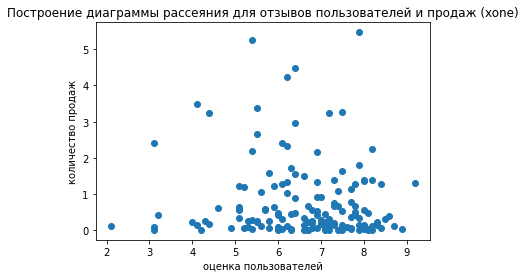

In [32]:
# Внутри одной платформы (например, xone)

# Создание подмножества данных для платформы xone
xone_data = filtered_data[filtered_data['Platform'] == 'xone']

# Удаление строки со значениями NaN в столбцах 'User_Score' и 'Critic_Score'
xone_data.dropna(subset=['User_Score', 'Critic_Score'], inplace=True)

# Построение диаграммы рассеяния для отзывов пользователей и продаж
plt.scatter(xone_data['User_Score'], xone_data['Total_Sales'])
plt.xlabel('оценка пользователей')
plt.ylabel('количество продаж')
plt.title('Построение диаграммы рассеяния для отзывов пользователей и продаж (xone)')
plt.show()

In [33]:
# Вычисление коэффициента корреляции между отзывами пользователей и продажами
correlation = xone_data['User_Score'].corr(xone_data['Total_Sales'])
print('Корреляция между отзывами пользователей и продажами:', correlation)

Корреляция между отзывами пользователей и продажами: -0.0917343450331075


In [34]:
# Вычисление коэффициента корреляции между оценкой критиков и продажами
correlation = xone_data['Critic_Score'].corr(xone_data['Total_Sales'])
print('Корреляция между оценкой критиков и продажами:', correlation)

Корреляция между оценкой критиков и продажами: 0.42211185105557647


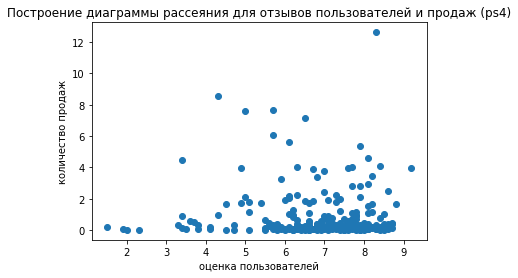

In [35]:
# Внутри одной платформы (например, ps4)

# Создание подмножества данных для платформы ps4
ps4_data = filtered_data[filtered_data['Platform'] == 'ps4']

# Удаление строки со значениями NaN в столбцах 'User_Score' и 'Critic_Score'
ps4_data.dropna(subset=['User_Score', 'Critic_Score'], inplace=True)

# Построение диаграммы рассеяния для отзывов пользователей и продаж
plt.scatter(ps4_data['User_Score'], ps4_data['Total_Sales'])
plt.xlabel('оценка пользователей')
plt.ylabel('количество продаж')
plt.title('Построение диаграммы рассеяния для отзывов пользователей и продаж (ps4)')
plt.show()

In [36]:
# Вычисление коэффициента корреляции между отзывами пользователей и продажами
correlation = ps4_data['User_Score'].corr(ps4_data['Total_Sales'])
print('Корреляция между отзывами пользователей и продажами:', correlation)

Корреляция между отзывами пользователей и продажами: -0.04318585997193634


In [37]:
# Вычисление коэффициента корреляции между оценкой критиков и продажами
correlation = ps4_data['Critic_Score'].corr(ps4_data['Total_Sales'])
print('Корреляция между оценкой критиков и продажами:', correlation)

Корреляция между оценкой критиков и продажами: 0.40190287811475334


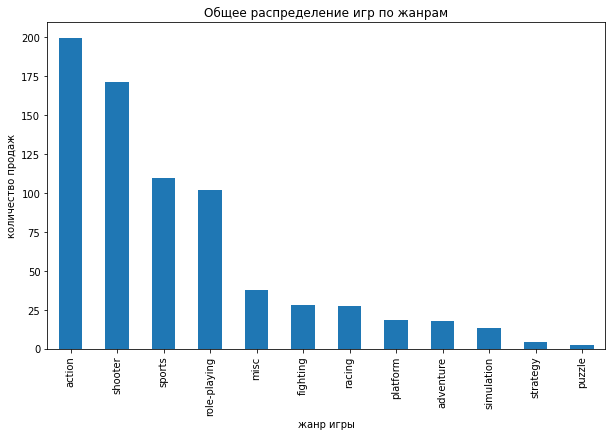

In [38]:
# Общее распределение игр по жанрам
genre_sales = filtered_data.groupby('Genre')['Total_Sales'].sum().sort_values(ascending=False)

# Построение диаграммы разделения жанров и продаж
genre_sales.plot(kind='bar', figsize=(10, 6))
plt.xlabel('жанр игры')
plt.ylabel('количество продаж')
plt.title('Общее распределение игр по жанрам')
plt.show()

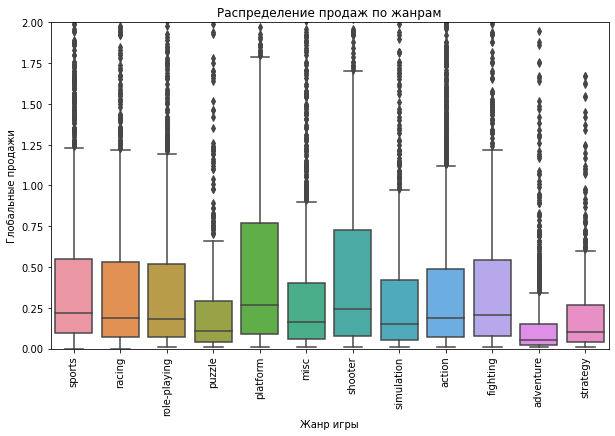

In [39]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=data['Genre'], y=data['Total_Sales'])
plt.xlabel('Жанр игры')
plt.ylabel('Глобальные продажи')
plt.title('Распределение продаж по жанрам')
plt.xticks(rotation=90)
plt.ylim(0,2)
plt.show()

In [40]:
# Вывод самых прибыльных жанров
top_genres = genre_sales.head(5)
print('Самые прибыльные жанры:')
print(top_genres)

# Вывод жанров с высокими и низкими продажами
high_sales_genres = genre_sales[genre_sales > genre_sales.mean()]
low_sales_genres = genre_sales[genre_sales < genre_sales.mean()]

print('Жанры с высокими продажами:')
print(high_sales_genres)

print('Жанры с низкими продажами:')
print(low_sales_genres)

Самые прибыльные жанры:
Genre
action          199.36
shooter         170.94
sports          109.48
role-playing    101.44
misc             37.55
Name: Total_Sales, dtype: float64
Жанры с высокими продажами:
Genre
action          199.36
shooter         170.94
sports          109.48
role-playing    101.44
Name: Total_Sales, dtype: float64
Жанры с низкими продажами:
Genre
misc          37.55
fighting      28.22
racing        27.52
platform      18.09
adventure     17.55
simulation    13.13
strategy       3.96
puzzle         2.21
Name: Total_Sales, dtype: float64


#### Вывод:
Все данные не важны, так как платформы и игры меняются от года.
Больше всего игр выпускалось с 2007 по 2010 год. Начиная с 2012 года по 2016, количество держиться на приблизительно одном уровне.
Топ 5 основных платформ чаще всего оставались в топе. Характерный срок для появления новых и исчезновение старых платформ - 10 лет. 
Платформы с наибольшими суммарными продажами: 'xone', 'psv', 'ps4', 'pc'. Периодически лидирует то одна то другая платформа. Умершие платформы:psv и psp. 
Самый большой квартильный размах у wii и ps4, далее xone и wiiu.
Самые прибыльные жанры: action, shooter, sports, role-playing и misc. Жанры с высокими продажами: action, shooter, sports и role-playing. Жанры с низкими продажами: misc,fighting,racing,platform,adventure,simulation,strategy и puzzle.
Корреляция между отзывами пользователей и продажами маленькая.
Корреляция между оценкой критиков и продажами указывает на умеренную положительную связь между этими двумя переменными.

## 4. Составим портрет пользователя каждого региона

Определите для пользователя каждого региона (NA, EU, JP):

In [41]:
# Самые популярные платформы (топ-5)
top_platforms_na = filtered_data.groupby('Platform')['NA_sales'].sum().nlargest(5)
top_platforms_eu = filtered_data.groupby('Platform')['EU_sales'].sum().nlargest(5)
top_platforms_jp = filtered_data.groupby('Platform')['JP_sales'].sum().nlargest(5)

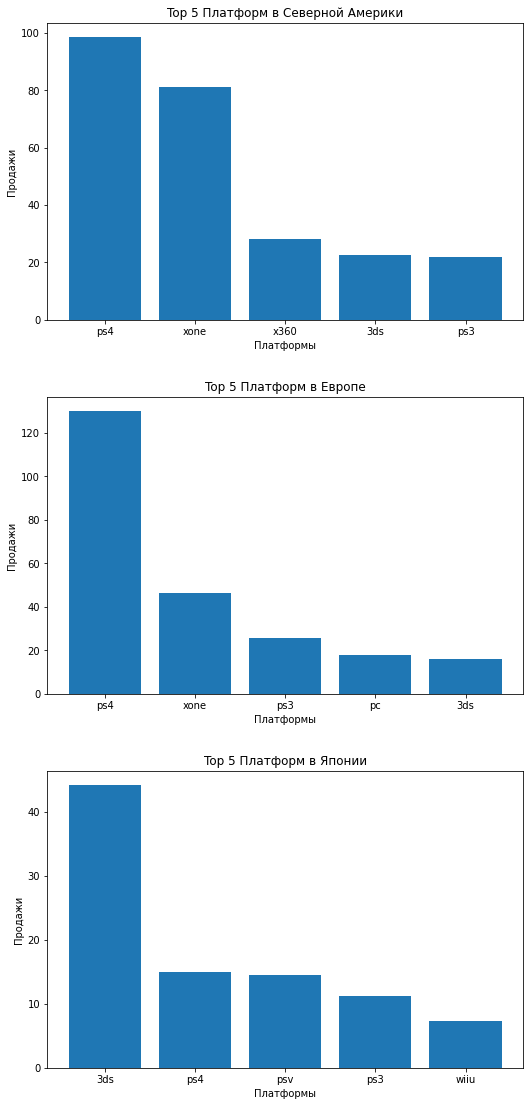

In [42]:
#Визуализация

# Создание подграфиков
fig, ax = plt.subplots(3, 1, figsize=(8, 16))

# Столбчатая диаграмма для Северной Америки
ax[0].bar(top_platforms_na.index, top_platforms_na.values)
ax[0].set_title('Top 5 Платформ в Северной Америки')
ax[0].set_xlabel('Платформы')
ax[0].set_ylabel('Продажи')

# Столбчатая диаграмма для Европы
ax[1].bar(top_platforms_eu.index, top_platforms_eu.values)
ax[1].set_title('Top 5 Платформ в Европе')
ax[1].set_xlabel('Платформы')
ax[1].set_ylabel('Продажи')

# Столбчатая диаграмма для Японии
ax[2].bar(top_platforms_jp.index, top_platforms_jp.values)
ax[2].set_title('Top 5 Платформ в Японии')
ax[2].set_xlabel('Платформы')
ax[2].set_ylabel('Продажи')

# Расположение и отступы между подграфиками
fig.tight_layout(pad=3.0)

# Отображение графиков
plt.show()


In [43]:
# Различия в долях продаж
sales_na_total = filtered_data['NA_sales'].sum()
sales_eu_total = filtered_data['EU_sales'].sum()
sales_jp_total = filtered_data['JP_sales'].sum()

sales_na_share = top_platforms_na / sales_na_total
sales_eu_share = top_platforms_eu / sales_eu_total
sales_jp_share = top_platforms_jp / sales_jp_total

print(sales_na_share)
print(sales_eu_share)
print(sales_jp_share)

Platform
ps4     0.347145
xone    0.286102
x360    0.099627
3ds     0.079701
ps3     0.077624
Name: NA_sales, dtype: float64
Platform
ps4     0.480420
xone    0.170866
ps3     0.094355
pc      0.066388
3ds     0.059554
Name: EU_sales, dtype: float64
Platform
3ds     0.475239
ps4     0.161349
psv     0.156193
ps3     0.120529
wiiu    0.078526
Name: JP_sales, dtype: float64


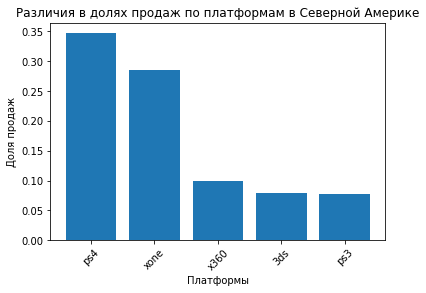

In [44]:
platforms = ['ps4', 'xone', 'x360', '3ds', 'ps3']

# Построение столбчатой диаграммы
plt.bar(platforms, sales_na_share)
plt.xlabel('Платформы')
plt.ylabel('Доля продаж')
plt.title('Различия в долях продаж по платформам в Северной Америке')

plt.xticks(rotation=45)

plt.show()


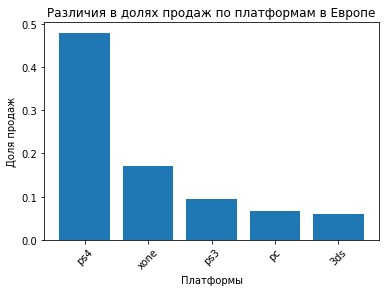

In [45]:
platforms = ['ps4', 'xone', 'ps3', 'pc', '3ds']

plt.bar(platforms, sales_eu_share)
plt.xlabel('Платформы')
plt.ylabel('Доля продаж')
plt.title('Различия в долях продаж по платформам в Европе')

plt.xticks(rotation=45)

plt.show()


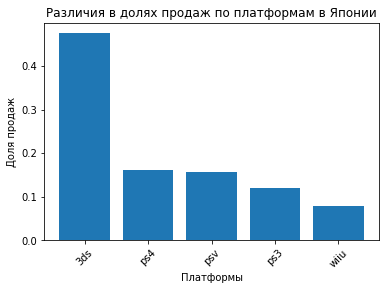

In [46]:
platforms = ['3ds', 'ps4', 'psv', 'ps3', 'wiiu']

plt.bar(platforms, sales_jp_share)
plt.xlabel('Платформы')
plt.ylabel('Доля продаж')
plt.title('Различия в долях продаж по платформам в Японии')

plt.xticks(rotation=45)

plt.show()


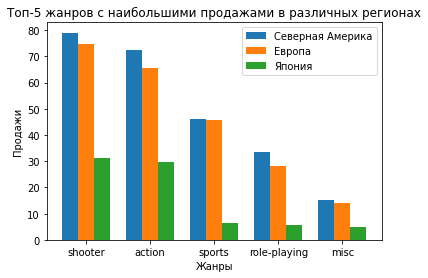

In [47]:
# Самые популярные жанры (топ-5)

# Получение топ-5 жанров с наибольшими продажами в каждом регионе
top_genres_na = filtered_data.groupby('Genre')['NA_sales'].sum().nlargest(5)
top_genres_eu = filtered_data.groupby('Genre')['EU_sales'].sum().nlargest(5)
top_genres_jp = filtered_data.groupby('Genre')['JP_sales'].sum().nlargest(5)

# Метки жанров
genres = top_genres_na.index

# Значения продаж для каждого региона
sales_na = top_genres_na.values
sales_eu = top_genres_eu.values
sales_jp = top_genres_jp.values

# Создание столбчатой диаграммы
bar_width = 0.25
index = np.arange(len(genres))

plt.bar(index - bar_width, sales_na, bar_width, label='Северная Америка')
plt.bar(index, sales_eu, bar_width, label='Европа')
plt.bar(index + bar_width, sales_jp, bar_width, label='Япония')

plt.xlabel('Жанры')
plt.ylabel('Продажи')
plt.title('Топ-5 жанров с наибольшими продажами в различных регионах')
plt.xticks(index, genres)
plt.legend()

# Отображение графика
plt.show()


In [48]:
# Разница в продажах жанров
genre_sales_na_share = top_genres_na / sales_na_total
genre_sales_eu_share = top_genres_eu / sales_eu_total
genre_sales_jp_share = top_genres_jp / sales_jp_total

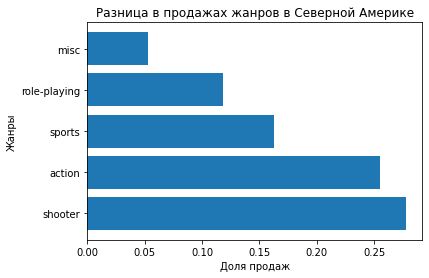

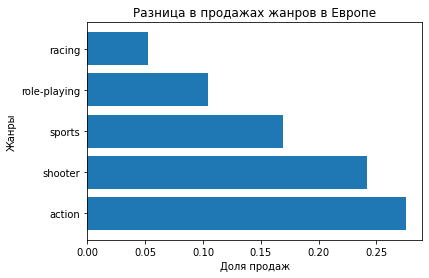

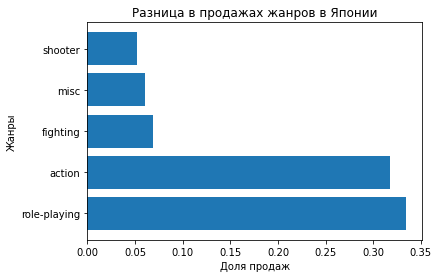

In [49]:
# Разница в продажах жанров по Северной Америке
plt.barh(top_genres_na.index, genre_sales_na_share)
plt.xlabel('Доля продаж')
plt.ylabel('Жанры')
plt.title('Разница в продажах жанров в Северной Америке')

# Отображение графика для Северной Америки
plt.show()

# Разница в продажах жанров по Европе
plt.barh(top_genres_eu.index, genre_sales_eu_share)
plt.xlabel('Доля продаж')
plt.ylabel('Жанры')
plt.title('Разница в продажах жанров в Европе')

# Отображение графика для Европы
plt.show()

# Разница в продажах жанров по Японии
plt.barh(top_genres_jp.index, genre_sales_jp_share)
plt.xlabel('Доля продаж')
plt.ylabel('Жанры')
plt.title('Разница в продажах жанров в Японии')

# Отображение графика для Японии
plt.show()


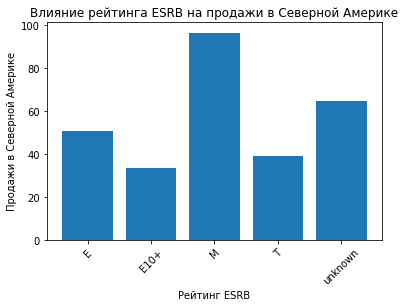

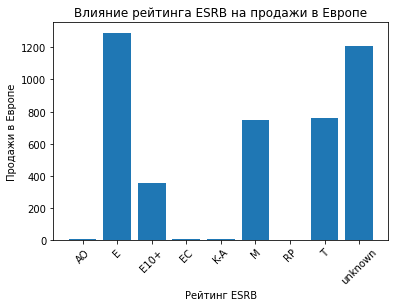

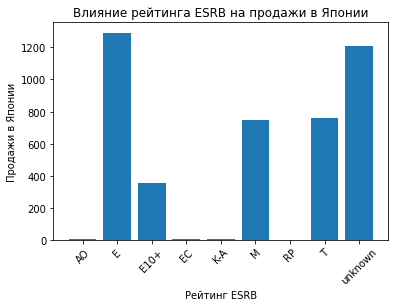

In [50]:
# Влияние рейтинга ESRB на продажи в Северной Америке
rating_sales_na = filtered_data.groupby('Rating')['NA_sales'].sum()

# Метки рейтингов
ratings = rating_sales_na.index

# Значения продаж
sales = rating_sales_na.values

# Создание столбчатой диаграммы
plt.bar(ratings, sales)
plt.xlabel('Рейтинг ESRB')
plt.ylabel('Продажи в Северной Америке')
plt.title('Влияние рейтинга ESRB на продажи в Северной Америке')

# Поворот меток оси X на 45 градусов для лучшей читаемости
plt.xticks(rotation=45)

# Отображение графика
plt.show()

# Влияние рейтинга ESRB на продажи в Европе
rating_sales_eu = data.groupby('Rating')['NA_sales'].sum()

# Метки рейтингов
ratings = rating_sales_eu.index

# Значения продаж
sales = rating_sales_eu.values

# Создание столбчатой диаграммы
plt.bar(ratings, sales)
plt.xlabel('Рейтинг ESRB')
plt.ylabel('Продажи в Европе')
plt.title('Влияние рейтинга ESRB на продажи в Европе')

# Поворот меток оси X на 45 градусов для лучшей читаемости
plt.xticks(rotation=45)

# Отображение графика
plt.show()


# Влияние рейтинга ESRB на продажи в Японии
rating_sales_jp = data.groupby('Rating')['NA_sales'].sum()

# Метки рейтингов
ratings = rating_sales_jp.index

# Значения продаж
sales = rating_sales_jp.values

# Создание столбчатой диаграммы
plt.bar(ratings, sales)
plt.xlabel('Рейтинг ESRB')
plt.ylabel('Продажи в Японии')
plt.title('Влияние рейтинга ESRB на продажи в Японии')

# Поворот меток оси X на 45 градусов для лучшей читаемости
plt.xticks(rotation=45)

# Отображение графика
plt.show()

###  Вывод
В Северной Америке самые популярные платформы: ps4, xone, x360,  3ds и ps3.
В Европе самые популярные платформы: ps4, xone, x360, pc и 3ds.
В Японии самые популярные платформы: 3ds, ps4, psv, ps3 и wiiu.
Европа и Северная Америка все таки обгоняют Японию по доступности наиболее современных платформ.
По популярности жанров: 
В Северной Америке самые популярные жанры:shooter, action, sports, role-playing, misc
В Европе самые популярные жанры:action, shooter, sports, role-playing, racing
В Японии самые популярные жанры: role-playing, action, fighting, misc, shooter
При анализе разницы по продажам по данным странам, выявила, что Северная Америка и Европа приблизительно одинаково продают вышеупомянутые жанры, в Японии на мервом месте role-playning. Думаю, это связанно с доступностью платформ в определенных странах для приобритения.
Рейтинг ESRB на продажи в отдельном регионе не особо влияет, так как не все на него ориентируются и по многим играм он не присваивается.

##  5. Проверим гипотезы

Гипотеза первая: Средние пользовательские рейтинги платформ Xbox One и PC одинаковые;
Для проверки гипотезы о равенстве средних пользовательских рейтингов платформ Xbox One и PC можно использовать t-тест для независимых выборок.

Нулевая гипотеза (H0): Средние пользовательские рейтинги платформ Xbox One и PC равны. Альтернативная гипотеза (H1): Средние пользовательские рейтинги платформ Xbox One и PC различны.

Для проверки гипотезы мы можем использовать двухвыборочный t-тест для независимых выборок. Этот критерий позволяет сравнить средние значения двух групп (в данном случае, рейтингов Xbox One и PC) и определить, есть ли статистически значимые различия между ними. Применение t-теста обосновано, если данные в обеих выборках имеют нормальное распределение и обладают примерно одинаковой дисперсией.

Нулевую гипотезу мы всегда выбираем как подтверждение гипотезы, а альтернативную- как не соотвествие.

In [51]:
# отфильтруем только необходимые столбцы (Platform и User_Score):
xbox_one_ratings = filtered_data[filtered_data['Platform'] == 'xone']['User_Score']
pc_ratings = filtered_data[filtered_data['Platform'] == 'pc']['User_Score']

print(xbox_one_ratings)
print(pc_ratings)

nan_percentage = filtered_data['User_Score'].isnull().mean() * 100
print(f"Процент значений NaN в столбце User_Score: {nan_percentage}%")

#Применим тест на равенство средних пользовательских рейтингов:
t_statistic, p_value = st.ttest_ind(xbox_one_ratings, pc_ratings, equal_var=False)
alpha = 0.05  # Уровень значимости

# Проверка гипотезы
if p_value < alpha:
    print("Отвергаем нулевую гипотезу, средние пользовательские рейтинги платформ Xbox One и PC различаются.")
else:
    print("Не удалось отвергнуть нулевую гипотезу, средние пользовательские рейтинги платформ Xbox One и PC равны.")
    
print("Значение p-value:", p_value)

99       NaN
165      7.9
179      5.4
242      6.4
270      6.2
        ... 
16630    8.2
16643    6.6
16645    NaN
16660    6.7
16672    NaN
Name: User_Score, Length: 228, dtype: float64
458      3.9
1530     5.4
1677     NaN
1730     7.9
2303     5.7
        ... 
16509    7.9
16518    1.4
16617    NaN
16631    NaN
16692    7.6
Name: User_Score, Length: 151, dtype: float64
Процент значений NaN в столбце User_Score: 47.42451154529307%
Не удалось отвергнуть нулевую гипотезу, средние пользовательские рейтинги платформ Xbox One и PC равны.
Значение p-value: nan


###### Вывод по гипотезе 1:
Считаю что полностью отвергнуть или принять гипотезу нет возможности, так как 47% рейтинговых значений отсутствует. Удалить данные значения и проверить гипотезу будет не верно, так как очень большой процент отсутсвия повлечет сильные изменения. Требуются данные максимум с 5% отсутствием.


Для проверки гипотезы о равенстве средних пользовательских рейтингов платформ Xbox One и PC использовался t-тест для независимых выборок. 
T-тест для независимых выборок является статистическим критерием, который позволяет сравнить средние значения двух независимых групп и определить, есть ли статистически значимые различия между ними. 
В данном случае мы сравниваем средние пользовательские рейтинги двух платформ (Xbox One и PC), и интересует, есть ли статистически значимая разница между ними.
Выбор t-теста для независимых выборок обусловлен тем, что у нас есть две независимые группы (Xbox One и PC), и мы хотим сравнить их средние значения.
При использовании t-теста для независимых выборок важно проверить несколько предпосылок:
1. Нормальность распределения данных в каждой группе. Мы предполагаем, что пользовательские рейтинги в каждой группе имеют нормальное распределение.
2. Однородность дисперсии между группами. Мы предполагаем, что дисперсия пользовательских рейтингов в каждой группе примерно одинакова.
Проверка этих предпосылок позволяет применить t-тест для независимых выборок и получить статистический вывод о равенстве или различии средних пользовательских рейтингов платформ Xbox One и PC.  

Гипотеза вторая: Средние пользовательские рейтинги жанров Action (англ. «действие», экшен-игры) и Sports (англ. «спортивные соревнования») разные.
Нулевая гипотеза (H0): Средние пользовательские рейтинги жанров Action и Sports одинаковы. Альтернативная гипотеза (H1): Средние пользовательские рейтинги жанров Action и Sports различаются.
Для проверки гипотезы о различии средних пользовательских рейтингов жанров Action и Sports, можно использовать t-тест для независимых выборок.

In [52]:
# Фильтрация данных по жанрам Action и Sports
action_games = filtered_data[filtered_data['Genre'] == 'action']
sports_games = filtered_data[filtered_data['Genre'] == 'sports']

# Извлечение пользовательских рейтингов для каждого жанра
action_user_scores = action_games['User_Score'].dropna()
sports_user_scores = sports_games['User_Score'].dropna()


# Проведение t-теста для независимых выборок
t_statistic, p_value = st.ttest_ind(action_user_scores, sports_user_scores)

# Задание уровня значимости
alpha = 0.05

# Проверка статистической значимости
if p_value < alpha:
    print("Отвергаем нулевую гипотезу")
    print("Средние пользовательские рейтинги жанров Action и Sports различаются")
else:
    print("Не отвергаем нулевую гипотезу")
    print("Средние пользовательские рейтинги жанров Action и Sports одинаковы")
print("Значение p-value:", p_value)

Отвергаем нулевую гипотезу
Средние пользовательские рейтинги жанров Action и Sports различаются
Значение p-value: 2.8711147985105864e-19


Для проверки этих гипотез будет применен t-тест для независимых выборок. Этот тест подходит, когда у нас есть две независимые группы наблюдений (в данном случае рейтингов) и мы хотим определить, есть ли различия между средними значениями этих групп.

Тест основан на предположении о нормальности распределения данных и одинаковой дисперсии в двух группах. Он позволяет вычислить t-статистику, которая указывает на степень различия между выборочными средними. Затем мы сравниваем полученное значение t-статистики с критическим значением для определения статистической значимости результатов.

В итоге, после проведения t-теста, мы сможем сделать вывод о статистической значимости различий между средними пользовательскими рейтингами жанров Action и Sports.

## 6. Общий вывод

  При получении файла некоторые столбцы привели к типу даты pandas, проверили наличие пропущенных значений и дубликатов в датафреймах и обработали их, проверила и удалила не явные дубликаты
  Все данные не важны, так как платформы и игры меняются от года.
Больше всего игр выпускалось с 2007 по 2010 год. Начиная с 2012 года по 2016, количество держиться на приблизительно одном уровне.
Топ 5 основных платформ чаще всего оставались в топе. Характерный срок для появления новых и исчезновение старых платформ - 10 лет. 
Платформы с наибольшими суммарными продажами: 'xone', 'psv', 'ps4', 'pc'. Периодически лидирует то одна то другая платформа. Умершие платформы:psv и psp.
Самый большой квартильный размах у wii и ps4, далее xone и wiiu. 
Самые прибыльные жанры: action, shooter, sports, role-playing и misc. Жанры с высокими продажами: action, shooter, sports и role-playing. Жанры с низкими продажами: misc,fighting,racing,platform,adventure,simulation,strategy и puzzle.
Корреляция между отзывами пользователей и продажами маленькая.
Корреляция между оценкой критиков и продажами указывает на умеренную положительную связь между этими двумя переменными.
  Составим портрет пользователя каждого региона:
В Северной Америке самые популярные платформы: ps4, xone, x360,  3ds и ps3.
В Европе самые популярные платформы: ps4, xone, x360, pc и 3ds.
В Японии самые популярные платформы: 3ds, ps4, psv, ps3 и wiiu.
Европа и Северная Америка все таки обгоняют Японию по доступности наиболее современных платформ.
По популярности жанров: 
В Северной Америке самые популярные жанры:shooter, action, sports, role-playing, misc
В Европе самые популярные жанры:action, shooter, sports, role-playing, racing
В Японии самые популярные жанры: role-playing, action, fighting, misc, shooter
При анализе разницы по продажам по данным странам, выявила, что Северная Америка и Европа приблизительно одинаково продают вышеупомянутые жанры, в Японии на мервом месте role-playning. Думаю, это связанно с доступностью платформ в определенных странах для приобритения.
Рейтинг ESRB на продажи в отдельном регионе не особо влияет, так как не все на него ориентируются и по многим играм он не присваивается.
  Считаю что полностью отвергнуть или принять гипотезу нет возможности, так как 47% рейтинговых значений отсутствует. Удалить данные значения и проверить гипотезу будет не верно, так как очень большой процент. Требуются данные максимум с 5% отсутствием.
  Средние пользовательские рейтинги жанров Action и Sports различаются.

Исходя из цели проекта: Выявить определяющие успешность закономерности для игр для планирования рекламных акций на следующий год. Вот они:
В Северной Америке самые популярные платформы: ps4, xone, x360,  3ds и ps3.
В Европе самые популярные платформы: ps4, xone, x360, pc и 3ds.
В Японии самые популярные платформы: 3ds, ps4, psv, ps3 и wiiu.
По популярности жанров: 
В Северной Америке самые популярные жанры:shooter, action, sports, role-playing, misc
В Европе самые популярные жанры:action, shooter, sports, role-playing, racing
В Японии самые популярные жанры: role-playing, action, fighting, misc, shooter
Корреляция между отзывами пользователей и продажами маленькая.
Корреляция между оценкой критиков и продажами указывает на умеренную положительную связь между этими двумя переменными.
Также считаю что следует обратить внимание на количество рекламных акций на самих платформах, так как они обладают большим влиянием на популярность игр.
Для проверки гипотез требуются данные по рейтингам данные максимум с 5% отсутствием данных.
Средние пользовательские рейтинги жанров Action и Sports различаются.